# Notebook 17 — Master Results: All Models × All Datasets (Thesis Source of Truth)

In [13]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

FIG = Path("../reports/figures"); TAB = Path("../reports/tables")
for d in (FIG, TAB): d.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 11})
INK = ["#2b2b2b", "#6f6f6f", "#a3a3a3", "#cccccc"]
HILITE = "#1a4f8a"

## 1. Multi-seed custom results (read real file if present, else embedded identical copy)

In [14]:
ms_path = Path("../checkpoints/multiseed/results.csv")
if ms_path.exists():
    seed_df = pd.read_csv(ms_path)
else:
    seed_df = pd.DataFrame({
        "seed":[42,43,44,45,46],
        "M0_EM":[0.20607,0.12516,0.18963,0.06700,0.21365],
        "M0_seenEM":[0.26504,0.16098,0.24390,0.08618,0.27480],
        "M0_CER":[0.45928,0.48403,0.46981,0.55716,0.43416],
        "M2_EM":[0.35145,0.29456,0.34766,0.19343,0.38812],
        "M2_seenEM":[0.45203,0.37886,0.44715,0.24878,0.49919],
        "M2_CER":[0.46482,0.48735,0.47054,0.58172,0.42862]})
def ms(c): return seed_df[c].mean(), seed_df[c].std(ddof=1)
m0_em, m0_sd = ms("M0_EM"); m2_em, m2_sd = ms("M2_EM")
m0_seen, _ = ms("M0_seenEM"); m2_seen, _ = ms("M2_seenEM")
m0_cer, _ = ms("M0_CER"); m2_cer, _ = ms("M2_CER")
print(f"custom multi-seed | M0 EM {m0_em:.3f}±{m0_sd:.3f} CER {m0_cer:.3f} | "
      f"M2 EM {m2_em:.3f}±{m2_sd:.3f} CER {m2_cer:.3f}")

custom multi-seed | M0 EM 0.160±0.063 CER 0.481 | M2 EM 0.315±0.076 CER 0.487


## 2. Confirmed results (custom dataset, from saved CSVs)
Each entry: CER, EM (overall), EM_sd (None if single run), seen, unseen, note.

In [42]:
custom = {
    "CRNN (baseline)":        {"CER": m0_cer, "EM": m0_em, "EM_sd": m0_sd, "seen": m0_seen, "unseen": 0.000, "note": "5-seed mean±std"},
    "CRNN + Transformer":     {"CER": 0.474,  "EM": 0.222, "EM_sd": None,  "seen": 0.287,   "unseen": 0.000, "note": "single (negative)"},
    "CRNN + BiLSTM + Transf": {"CER": 0.597,  "EM": 0.140, "EM_sd": None,  "seen": 0.181,   "unseen": 0.000, "note": "single (negative)"},
    "Attention decoder":      {"CER": 0.846,  "EM": 0.106, "EM_sd": None,  "seen": 0.000,   "unseen": 0.000, "note": "single (failed)"},
    "CRNN + lexicon":         {"CER": m2_cer, "EM": m2_em, "EM_sd": m2_sd, "seen": m2_seen, "unseen": 0.000, "note": "5-seed mean±std"},
     "CNN-ViT -CTC":           {"CER": 0.691,  "EM": 0.119, "EM_sd": None,  "seen": 0.134,   "unseen": 0.000, "note": "Hybrid (negative)"},
    "CNN-BiLSTM -CTC ":       {"CER": 0.683,  "EM": 0.111, "EM_sd": None,  "seen": 0.136,   "unseen": 0.000, "note": "Hybrid (negative)"},
    "TrOCR (fine-tuned)":     {"CER": 0.286,  "EM": 0.539, "EM_sd": None,  "seen": 0.701,   "unseen": 0.108, "note": "61.6M params"},
    "FUSION (proposed)":      {"CER": 0.234,  "EM": 0.609, "EM_sd": None,  "seen": 0.784,   "unseen": 0.000, "note": "PROPOSED NOVELTY"},
   
}

## 2.1  >>> ADD YOUR EARLIER MODELS HERE <<<
Fill in any earlier models you ran. Copy the template line, change the name and numbers.
`EM_sd`: use None for a single run, or a number for multi-seed std.
If you don't have seen/unseen for a model, set them to the same as EM or to 0.0 (and note it).
Everything below (tables + plots) updates automatically once you add lines here.

In [4]:
extra_models = {
    # ----------------- TEMPLATE (delete the # and edit) -----------------
    # "My Earlier Model Name": {"CER": 0.00, "EM": 0.00, "EM_sd": None, "seen": 0.00, "unseen": 0.00, "note": "describe it"},
    # "ResNet-CRNN (early)":   {"CER": 0.40, "EM": 0.20, "EM_sd": None, "seen": 0.25, "unseen": 0.00, "note": "earlier experiment"},
    # --------------------------------------------------------------------
}
custom.update(extra_models)
print(f"{len(custom)} models in the custom comparison "
      f"({len(extra_models)} added by you).")

7 models in the custom comparison (0 added by you).


## 3. Master comparison table (overall metrics led; seen/unseen included as columns)

In [39]:
def fmt(v, sd): return f"{v:.3f} ± {sd:.3f}" if sd is not None else f"{v:.3f}"
rows = [{"Model": k, "CER": f"{d['CER']:.3f}", "Exact Match (overall)": fmt(d["EM"], d["EM_sd"]),
         "Seen EM": f"{d['seen']:.3f}", "Unseen EM": f"{d['unseen']:.3f}", "Notes": d["note"]}
        for k, d in custom.items()]
master = pd.DataFrame(rows)
master.to_csv(TAB / "master_comparison_custom.csv", index=False)
print(master.to_string(index=False))

                 Model   CER Exact Match (overall) Seen EM Unseen EM             Notes
       CRNN (baseline) 0.481         0.160 ± 0.063   0.206     0.000   5-seed mean±std
    CRNN + Transformer 0.474                 0.222   0.287     0.000 single (negative)
CRNN + BiLSTM + Transf 0.597                 0.140   0.181     0.000 single (negative)
     Attention decoder 0.846                 0.106   0.000     0.000   single (failed)
        CRNN + lexicon 0.487         0.315 ± 0.076   0.405     0.000   5-seed mean±std
          CNN-ViT -CTC 0.691                 0.119   0.134     0.000 Hybrid (negative)
      CNN-BiLSTM -CTC  0.683                 0.111   0.136     0.000 Hybrid (negative)
    TrOCR (fine-tuned) 0.286                 0.569   0.701     0.108      61.6M params
     FUSION (proposed) 0.234                 0.609   0.784     0.000  PROPOSED NOVELTY


## 4. HEADLINE Figure 1 — Overall Exact-Match by model (Fusion highlighted)

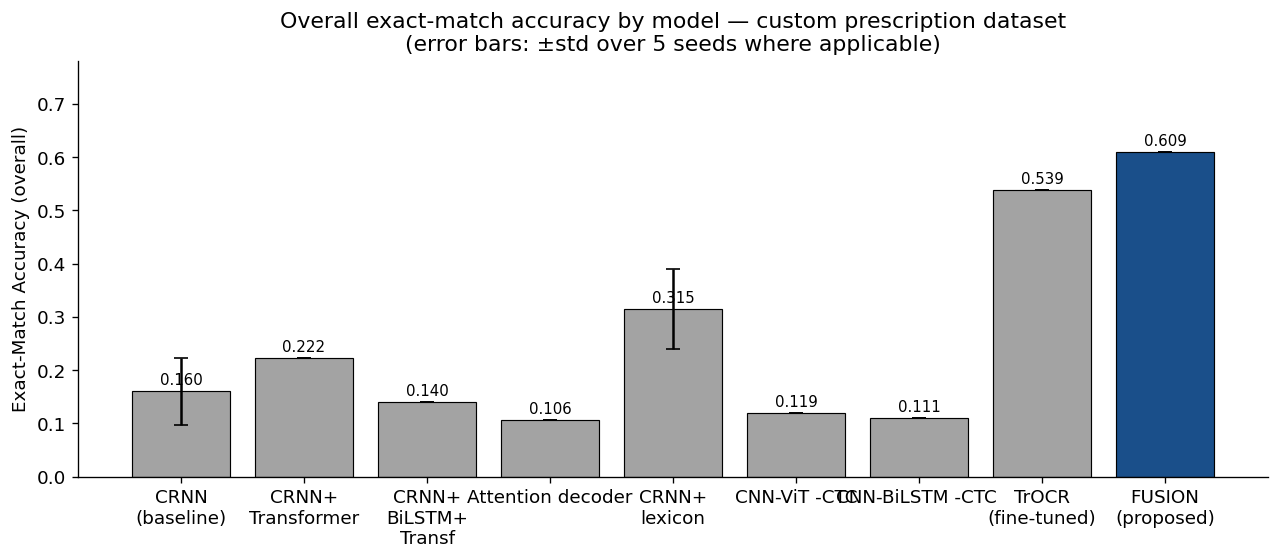

In [43]:
names = list(custom.keys())
short = [n.replace(" + ", "+\n").replace(" (", "\n(") for n in names]
ems = [custom[n]["EM"] for n in names]
sds = [custom[n]["EM_sd"] or 0 for n in names]
colors = [HILITE if "FUSION" in n else INK[2] for n in names]
fig, ax = plt.subplots(figsize=(max(9, len(names)*1.2), 4.8))
bars = ax.bar(short, ems, yerr=sds, capsize=4, color=colors, edgecolor="black", linewidth=0.7)
for b, v in zip(bars, ems):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Exact-Match Accuracy (overall)"); ax.set_ylim(0, max(ems)*1.2 + 0.05)
ax.set_title("Overall exact-match accuracy by model — custom prescription dataset\n(error bars: ±std over 5 seeds where applicable)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / "fig1_overall_exactmatch.png"); plt.show()

## 5. HEADLINE Figure 2 — Overall CER by model (lower = better)

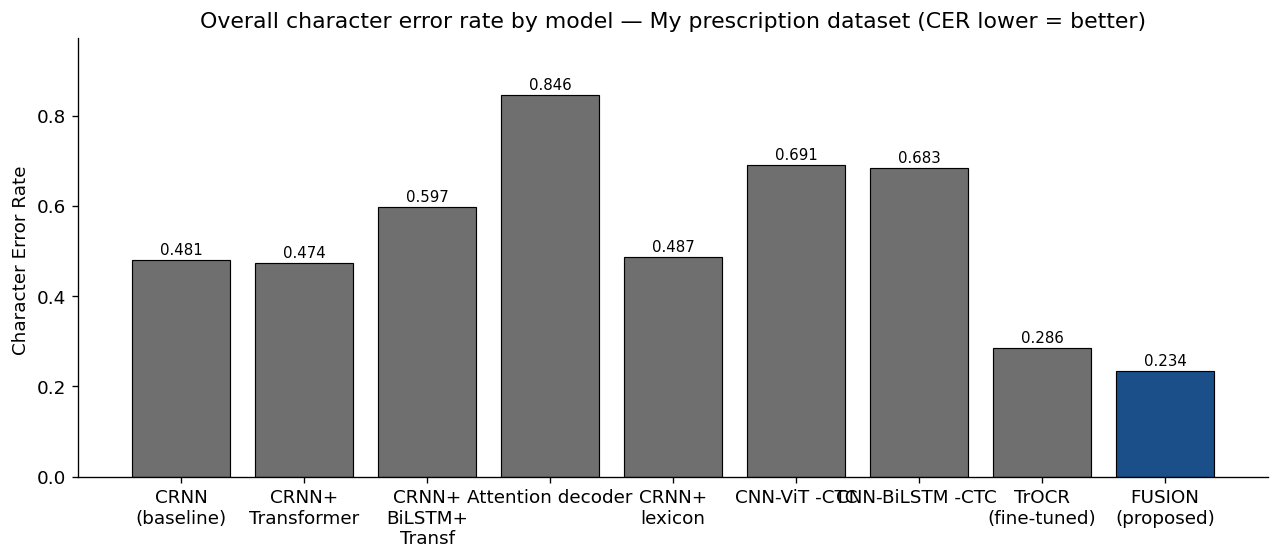

In [41]:
cers = [custom[n]["CER"] for n in names]
colors2 = [HILITE if "FUSION" in n else INK[1] for n in names]
fig, ax = plt.subplots(figsize=(max(9, len(names)*1.2), 4.8))
bars = ax.bar(short, cers, color=colors2, edgecolor="black", linewidth=0.7)
for b, v in zip(bars, cers):
    ax.text(b.get_x()+b.get_width()/2, v+0.012, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("Character Error Rate "); ax.set_ylim(0, max(cers)*1.15)
ax.set_title("Overall character error rate by model — My prescription dataset (CER lower = better)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / "fig2_overall_cer.png"); plt.show()

## 6. Cross-dataset figures (generality + domain gap)

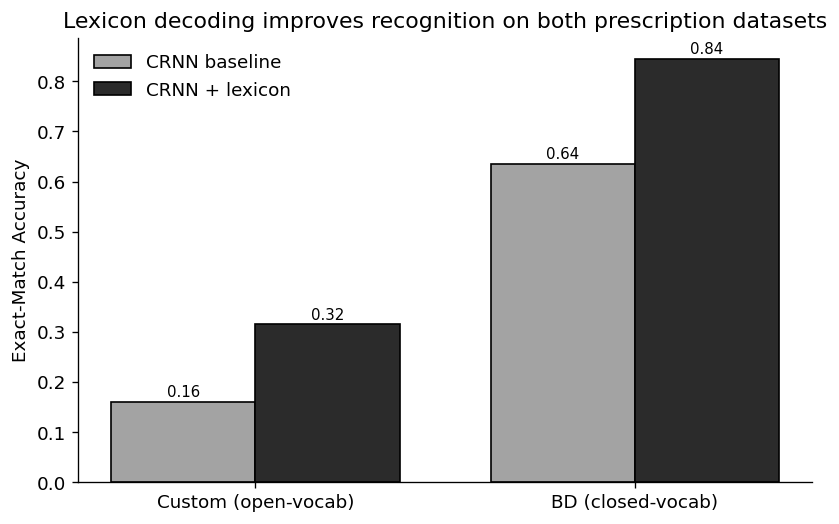

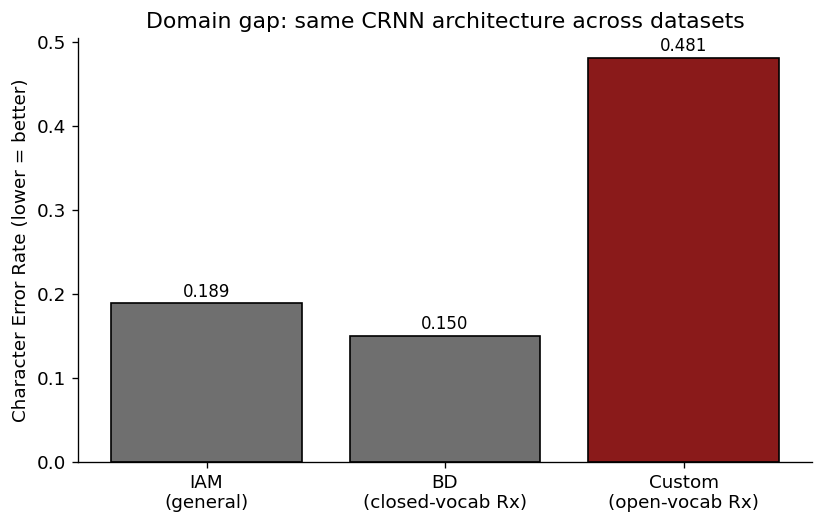

In [32]:
# Generality: CRNN vs CRNN+lexicon on both prescription datasets
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(2); w = 0.38
base = [m0_em, 0.636]; lex = [m2_em, 0.845]
ax.bar(x-w/2, base, w, label="CRNN baseline", color=INK[2], edgecolor="black")
ax.bar(x+w/2, lex, w, label="CRNN + lexicon", color=INK[0], edgecolor="black")
ax.set_xticks(x); ax.set_xticklabels(["Custom (open-vocab)","BD (closed-vocab)"])
ax.set_ylabel("Exact-Match Accuracy"); ax.legend(frameon=False)
for i,(b,l) in enumerate(zip(base,lex)):
    ax.text(i-w/2, b+0.01, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i+w/2, l+0.01, f"{l:.2f}", ha="center", fontsize=9)
ax.set_title("Lexicon decoding improves recognition on both prescription datasets")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / "fig3_generality.png"); plt.show()

# Domain gap: same CRNN across three datasets (CER)
fig, ax = plt.subplots(figsize=(7, 4.5))
dgs = ["IAM\n(general)", "BD\n(closed-vocab Rx)", "Custom\n(open-vocab Rx)"]
dcer = [0.189, 0.150, m0_cer]
bars = ax.bar(dgs, dcer, color=[INK[1], INK[1], "#8a1a1a"], edgecolor="black")
for b, v in zip(bars, dcer):
    ax.text(b.get_x()+b.get_width()/2, v+0.008, f"{v:.3f}", ha="center", fontsize=10)
ax.set_ylabel("Character Error Rate (lower = better)")
ax.set_title("Domain gap: same CRNN architecture across datasets")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout(); plt.savefig(FIG / "fig4_domain_gap.png"); plt.show()

## 7. Significance (custom M0 vs M2, multi-seed)

In [33]:
t, p = stats.ttest_rel(seed_df["M2_EM"], seed_df["M0_EM"])
sig = pd.DataFrame([{"comparison":"CRNN+lexicon vs CRNN (paired t-test, per-seed EM)",
                     "t": round(t,3), "p_value": f"{p:.5f}", "n_seeds": len(seed_df)}])
sig.to_csv(TAB / "significance.csv", index=False)
print(sig.to_string(index=False))

                                       comparison      t p_value  n_seeds
CRNN+lexicon vs CRNN (paired t-test, per-seed EM) 17.842 0.00006        5


## 8. BD + IAM tables

In [34]:
bd_df = pd.DataFrame({"CRNN (baseline)":{"CER":0.150,"EM":0.636},
                      "CRNN + lexicon":{"CER":0.112,"EM":0.845},
                      "TrOCR (fine-tuned)":{"CER":0.046,"EM":0.941}}).T.reset_index().rename(columns={"index":"Model"})
bd_df.to_csv(TAB / "bd_results.csv", index=False)
print("BD:"); print(bd_df.to_string(index=False))
pd.DataFrame([{"dataset":"IAM-subset(10k)","CER":0.189,"EM":0.561}]).to_csv(TAB / "iam_results.csv", index=False)
print("\nIAM: CER 0.189 | EM 0.561")

BD:
             Model   CER    EM
   CRNN (baseline) 0.150 0.636
    CRNN + lexicon 0.112 0.845
TrOCR (fine-tuned) 0.046 0.941

IAM: CER 0.189 | EM 0.561


## 9. OPTIONAL secondary section — seen vs unseen breakdown
This is the analysis subsection material (NOT a headline figure). It documents the
open-vocabulary challenge honestly. Include it in a dedicated Results subsection or appendix,
framed as "performance by vocabulary type" — evidence for the research challenge, not a
headline metric. Set MAKE_SEEN_UNSEEN = True to render it.

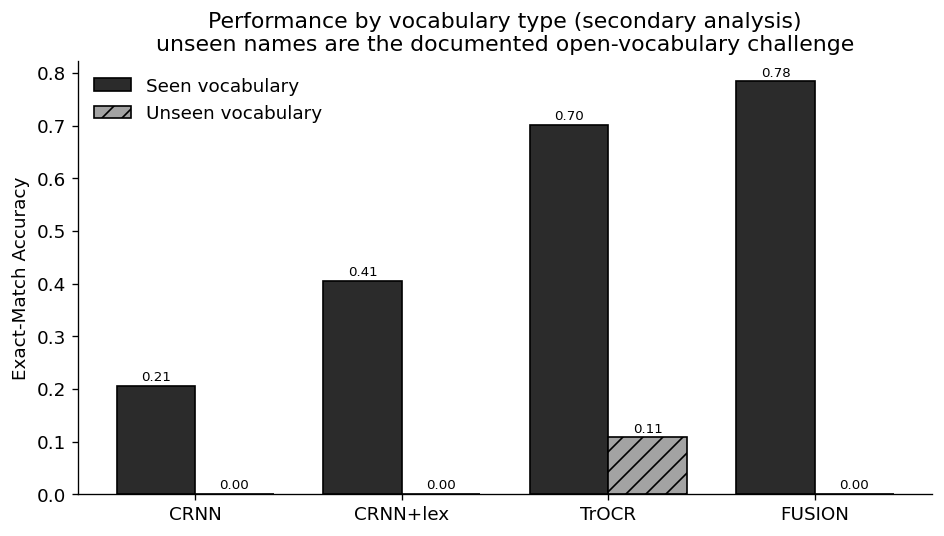


DONE. Headline figures: fig1 (overall EM), fig2 (overall CER), fig3 (generality), fig4 (domain gap).
Secondary: fig5 (seen/unseen). Tables in reports/tables/.


In [35]:
MAKE_SEEN_UNSEEN = True   # set False to skip
if MAKE_SEEN_UNSEEN:
    sel = ["CRNN (baseline)","CRNN + lexicon","TrOCR (fine-tuned)","FUSION (proposed)"]
    sl = ["CRNN","CRNN+lex","TrOCR","FUSION"]
    seen = [custom[m]["seen"] for m in sel]; unseen = [custom[m]["unseen"] for m in sel]
    x = np.arange(len(sel)); w = 0.38
    fig, ax = plt.subplots(figsize=(8, 4.6))
    ax.bar(x-w/2, seen, w, label="Seen vocabulary", color=INK[0], edgecolor="black")
    ax.bar(x+w/2, unseen, w, label="Unseen vocabulary", color=INK[2], edgecolor="black", hatch="//")
    ax.set_xticks(x); ax.set_xticklabels(sl); ax.set_ylabel("Exact-Match Accuracy")
    ax.set_title("Performance by vocabulary type (secondary analysis)\nunseen names are the documented open-vocabulary challenge")
    ax.legend(frameon=False)
    for i,(s,u) in enumerate(zip(seen,unseen)):
        ax.text(i-w/2, s+0.01, f"{s:.2f}", ha="center", fontsize=8)
        ax.text(i+w/2, u+0.01, f"{u:.2f}", ha="center", fontsize=8)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout(); plt.savefig(FIG / "fig5_seen_unseen_secondary.png"); plt.show()

print("\nDONE. Headline figures: fig1 (overall EM), fig2 (overall CER), fig3 (generality), fig4 (domain gap).")
print("Secondary: fig5 (seen/unseen). Tables in reports/tables/.")